# 2.5 Kernel Density Estimation

In this notebook we use Kernel Density Estimation to identify trip demand hotspots.

### Data Requirements:

This notebook requires the following files: 

1. `01_06_trips_weather_merged.parquet` — local path: `data/merged/01_06_trips_weather_merged.parquet` — Sciebo path: `data_parquet/merged/01_06_trips_weather_merged.parquet`

2. `Boundaries_Community_Areas_20260608.geojson` — local path: `data/geometry/Boundaries_Community_Areas_20260608.geojson` — Sciebo path: `data_parquet/geometry/Boundaries_Community_Areas_20260608.geojson`

Sample data is provided in the appropriate locations for testing purposes only. It will not produce meaningful results.

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [36]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: C:\Users\Yannick Herrmann\Documents\Uni\AAA\AAA_Project\AAA_TA_2026


In [37]:
if Path("data/merged/01_06_trips_weather_merged.parquet").exists():
    df = pd.read_parquet("data/merged/01_06_trips_weather_merged.parquet")
else:
    df = pd.read_parquet("data/samples/SAMPLE_01_06_trips_weather_merged.parquet")

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5369356 entries, 0 to 5369355
Data columns (total 41 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   trip_id                     str           
 1   taxi_id                     str           
 2   trip_start_timestamp        datetime64[ns]
 3   trip_end_timestamp          datetime64[ns]
 4   trip_seconds                float64       
 5   trip_miles                  float64       
 6   pickup_census_tract         string        
 7   dropoff_census_tract        string        
 8   pickup_community_area       int64         
 9   dropoff_community_area      int64         
 10  fare                        float64       
 11  tips                        float64       
 12  tolls                       float64       
 13  extras                      float64       
 14  trip_total                  float64       
 15  payment_type                str           
 16  company                     s

In [39]:
df["start_hour"] = df["trip_start_timestamp"].dt.hour

In [40]:

areas = gpd.read_file("data/geometry/Boundaries_Community_Areas_20260608.geojson").to_crs(3857)

areas

,:id,:version,:created_at,:updated_at,area_numbe,community,area_num_1,shape_area,shape_len,geometry
0,row-m77e_pkv8.vjvf,rv-3hjp_vkhx~fqfx,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,1,ROGERS PARK,1,51259902.4506,34052.3975757,"MULTIPOLYGON (((-9757660.529 5160704.746, -975..."
1,row-u375_347e-y6q8,rv-tgcx_t7fr-nkkg,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,2,WEST RIDGE,2,98429094.8621,43020.6894583,"MULTIPOLYGON (((-9761010.933 5163898.616, -976..."
2,row-kgqf-m29p-99kg,rv-bag4-8zri.nvhu,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,3,UPTOWN,3,65095642.7289,46972.7945549,"MULTIPOLYGON (((-9756154.198 5154211.526, -975..."
3,row-2dpv_pk9x-zybp,rv-82s2~rb54~emuc,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,4,LINCOLN SQUARE,4,71352328.2399,36624.6030848,"MULTIPOLYGON (((-9759870.406 5157400.522, -975..."
4,row-37zy.7r75.56p7,rv-hrse.ahu7-rz4d,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,5,NORTH CENTER,5,57054167.85,31391.6697542,"MULTIPOLYGON (((-9759754.254 5150850.097, -975..."
...,...,...,...,...,...,...,...,...,...,...
72,row-3uma_gs6v_expc,rv-cj4p_x3rj.brzz,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,73,WASHINGTON HEIGHTS,73,79635752.8769,42222.598163,"MULTIPOLYGON (((-9755342.627 5120449.037, -975..."
73,row-rn7j_sh22-jf8y,rv-a49v.s4vy~pudv,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,74,MOUNT GREENWOOD,74,75584290.0209,48665.1305392,"MULTIPOLYGON (((-9762325.229 5117211.619, -976..."
74,row-fiv3~fa4r~zk9e,rv-vip3.c98b.9m2d,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,75,MORGAN PARK,75,91877340.6988,46396.419362,"MULTIPOLYGON (((-9756279.738 5113922.382, -975..."
75,row-wewr.7jx4_gctv,rv-awj9_vhn6~tvpk,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,76,OHARE,76,371835607.687,173625.98466,"MULTIPOLYGON (((-9777923.456 5158941.865, -977..."


In [41]:
# calculate demand per census tract (if available) and community area (otherwise) since coordinates are the centroids of census tracts or community areas. 
# calculating KDE for > 5 million rows individually would be too demanding
tract_demand = (
    df[df["pickup_census_tract"].notna()].groupby("pickup_census_tract")
      .size()
      .reset_index(name="trip_count")
)

tract_centroids = (
    df[df["pickup_census_tract"].notna()].groupby("pickup_census_tract")[["pickup_centroid_latitude", "pickup_centroid_longitude"]]
      .first()
      .reset_index()
)

area_demand = (
    df[df["pickup_census_tract"].isna()].groupby("pickup_community_area")
      .size()
      .reset_index(name="trip_count")
)

area_centroids = (
    df[df["pickup_census_tract"].isna()].groupby("pickup_community_area")[["pickup_centroid_latitude", "pickup_centroid_longitude"]]
      .first()
      .reset_index()
)
tract_demand = tract_demand.merge(tract_centroids, on="pickup_census_tract")
area_demand = area_demand.merge(area_centroids, on="pickup_community_area")

# combine demand of census tracts and community areas for the full demand
demand = pd.concat([
    tract_demand[['trip_count', 'pickup_centroid_latitude', 'pickup_centroid_longitude']],
    area_demand[['trip_count', 'pickup_centroid_latitude', 'pickup_centroid_longitude']]
], ignore_index=True)

## KDE Visualization

In [42]:
from scipy.stats import gaussian_kde

# implement KDE using weighted community area coordinates
xy = demand[["pickup_centroid_longitude", "pickup_centroid_latitude"]].values.T
weights = demand["trip_count"].values / demand["trip_count"].sum()

kde = gaussian_kde(xy, bw_method=0.1, weights=weights)

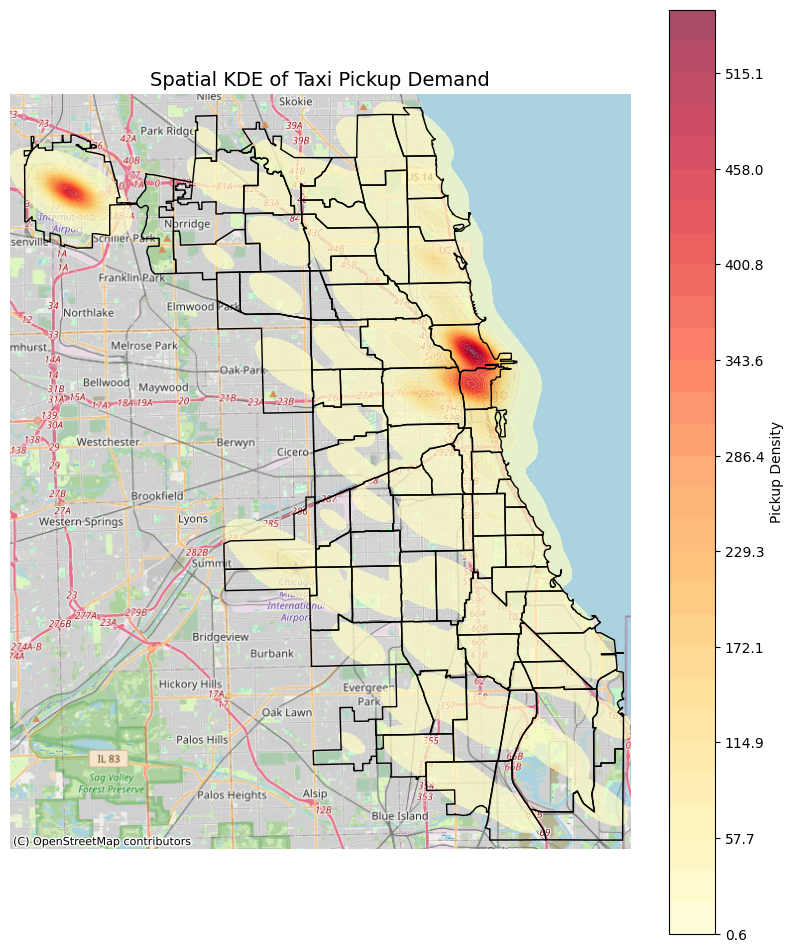

In [43]:
from shapely.geometry import Point
import contextily as cx

# evaluate KDE using an even grid over chicago
lon_min, lon_max = -87.95, -87.52
lat_min, lat_max = 41.64, 42.03

lon_grid = np.linspace(lon_min, lon_max, 300)
lat_grid = np.linspace(lat_min, lat_max, 300)
xx, yy = np.meshgrid(lon_grid, lat_grid)
zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

# convert the grid to mercator
gdf_grid = gpd.GeoDataFrame(
    geometry=[Point(lon, lat) for lon, lat in zip(xx.ravel(), yy.ravel())],
    crs="EPSG:4326"
).to_crs(epsg=3857)

xs = gdf_grid.geometry.x.values.reshape(xx.shape)
ys = gdf_grid.geometry.y.values.reshape(xx.shape)

# plot the kde distribution on the chicago map, including the community area shapes
fig, ax = plt.subplots(figsize=(10, 12))

# Highlight only the highest-density regions (top 30% of zz values)
levels = np.linspace(np.percentile(zz, 70), zz.max(), 30)

contour = ax.contourf(xs, ys, zz, levels=levels, cmap="YlOrRd", alpha=0.7)

plt.colorbar(contour, ax=ax, label= "Pickup Density")

cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
areas.plot(ax = ax, facecolor="none", edgecolor="k")
ax.set_title("Spatial KDE of Taxi Pickup Demand", fontsize=14)
ax.set_axis_off()
plt.show()

Since the coordinates for each trip are the centroid coordinates of the corresponding community, instead of being exact coordinates, this visualization does not offer many new insights compared to the choropleth maps.

## Hotspots for different times of day

In [44]:
# create bins for different times of day
bins = {
    "Night (0–6)":         (0, 6),
    "Morning (6–12)":      (6, 12),
    "Afternoon (12–18)":   (12, 18),
    "Evening (18–24)":     (18, 24),
}

In [45]:

# compute demand and kde per time of day - bin
bin_demands = {}
bin_kdes = {}
for label, (h_start, h_end) in bins.items():
    subset = df[(df["start_hour"] >= h_start) & (df["start_hour"] < h_end)]


    tract_demand = (
        subset[subset["pickup_census_tract"].notna()].groupby("pickup_census_tract")
        .size()
        .reset_index(name="trip_count")
    )

    tract_centroids = (
        subset[subset["pickup_census_tract"].notna()].groupby("pickup_census_tract")[["pickup_centroid_latitude", "pickup_centroid_longitude"]]
        .first()
        .reset_index()
    )

    area_demand = (
        subset[subset["pickup_census_tract"].isna()].groupby("pickup_community_area")
        .size()
        .reset_index(name="trip_count")
    )

    area_centroids = (
        subset[subset["pickup_census_tract"].isna()].groupby("pickup_community_area")[["pickup_centroid_latitude", "pickup_centroid_longitude"]]
        .first()
        .reset_index()
    )
    tract_demand = tract_demand.merge(tract_centroids, on="pickup_census_tract")
    area_demand = area_demand.merge(area_centroids, on="pickup_community_area")

    # combine demand of census tracts and community areas for the full demand
    demand = pd.concat([
        tract_demand[['trip_count', 'pickup_centroid_latitude', 'pickup_centroid_longitude']],
        area_demand[['trip_count', 'pickup_centroid_latitude', 'pickup_centroid_longitude']]
    ], ignore_index=True)

    bin_demands[label] = demand

    xy = demand[["pickup_centroid_longitude", "pickup_centroid_latitude"]].values.T
    weights = demand["trip_count"].values / demand["trip_count"].sum()

    bin_kdes[label] = gaussian_kde(xy, bw_method=0.1, weights=weights)

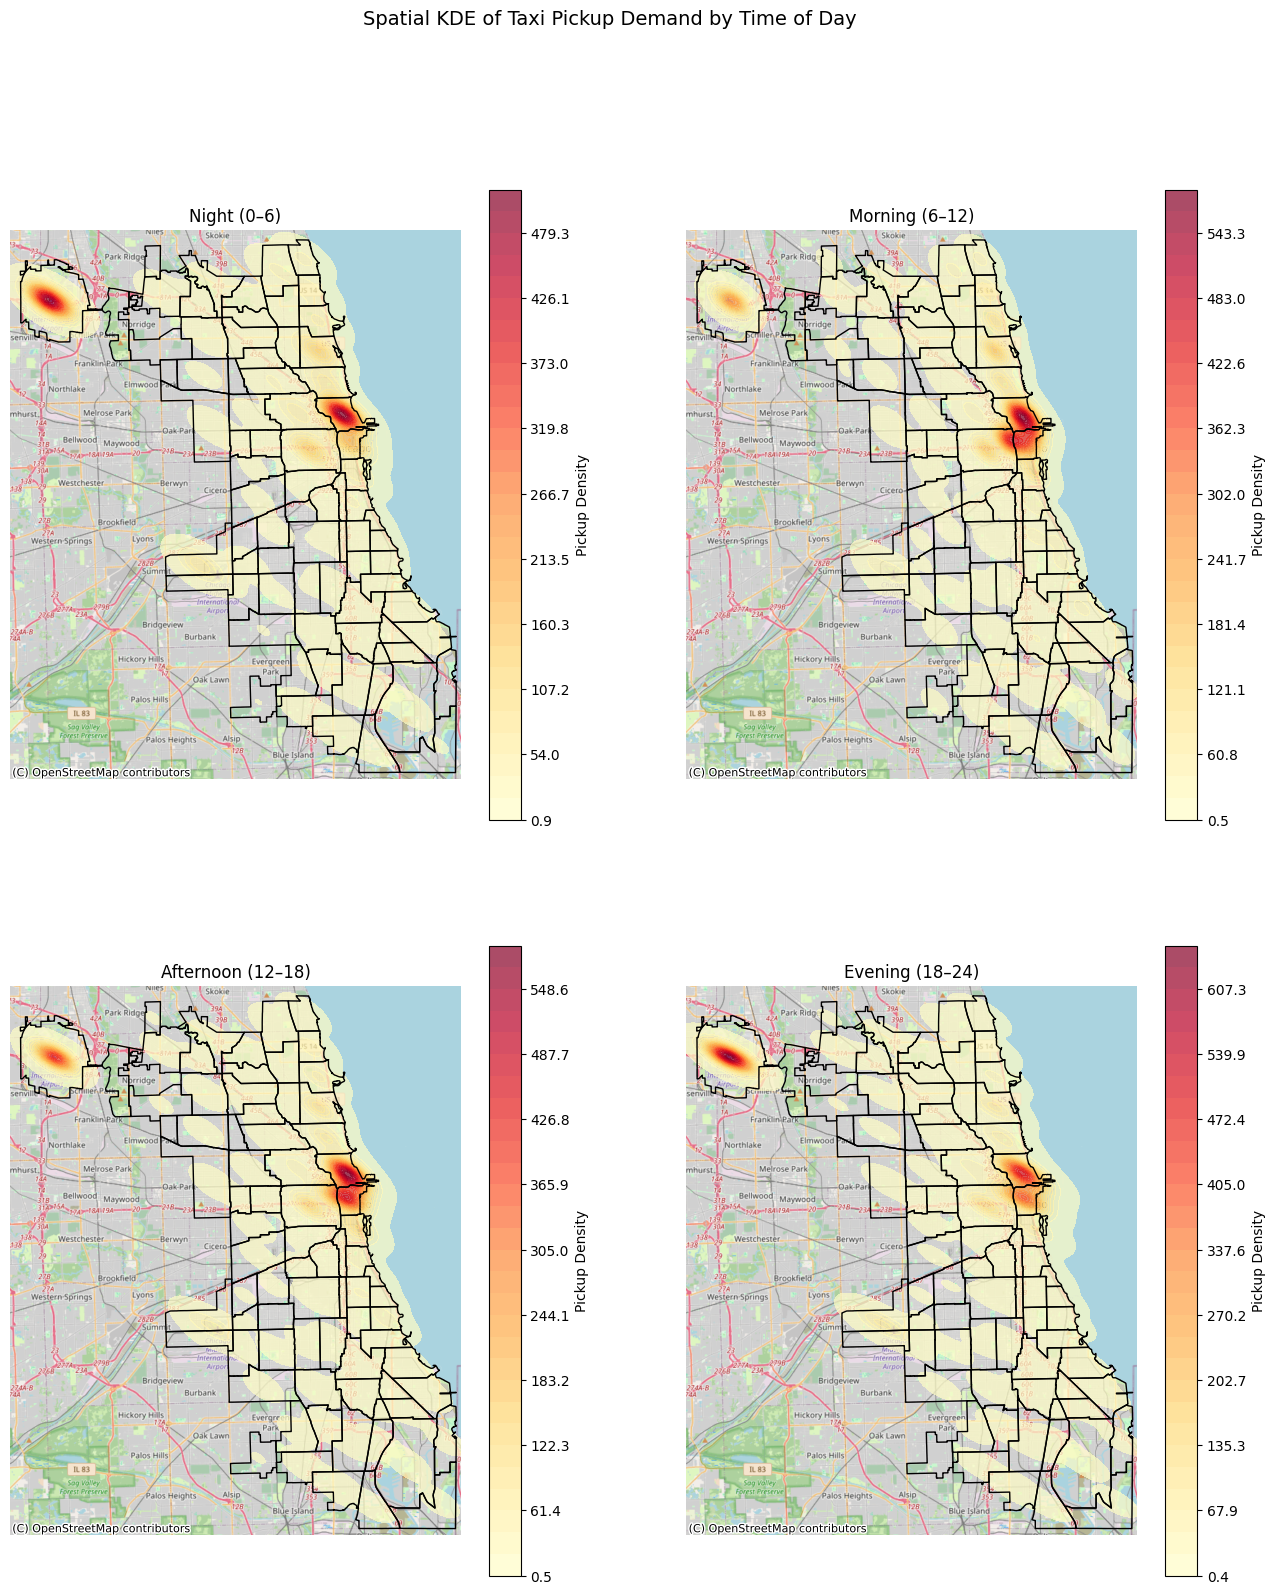

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(16, 18))

# plot the KDE visualisation per time bin, including community area shapes
for ax, label in zip(axes.flat, bins.keys()):

    # compute the zz value per bin
    zz = bin_kdes[label](np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

    # Highlight only the highest-density regions (top 30% of zz values)
    levels = np.linspace(np.percentile(zz, 70), zz.max(), 30)

    contour = ax.contourf(xs, ys, zz, levels=levels, cmap="YlOrRd", alpha=0.7)

    plt.colorbar(contour, ax=ax, label= "Pickup Density")

    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
    areas.plot(ax = ax, facecolor="none", edgecolor="k")
    ax.set_axis_off()
    ax.set_title(label)
    
plt.suptitle("Spatial KDE of Taxi Pickup Demand by Time of Day", fontsize=14)

plt.show()

# Finding Hotspots: Distributing Trips Within Their Areas

The KDE above collapses every trip onto its area's centroid, so it can only echo the choropleth pattern — a few hundred stacked points. Because we know only the *centroid* of each trip's spatial area (not the true pickup coordinate), we can recover a far more realistic demand surface by scattering each area's trips **uniformly at random inside the area's actual polygon**.

We use the finest spatial unit the dataset provides: where a trip carries a **census tract** we scatter it inside that (smaller, more precise) polygon; otherwise we fall back to the (larger) **community area**. The code below auto-detects which is present — the current merged dataset only carries the community area, so trips are distributed at that level.

This removes the centroid artifact and lets both the KDE and a Gaussian Mixture Model expose genuine spatial **hotspots**. All spatial operations below are done in a metric CRS (EPSG:3857) so that distances, densities and cluster shapes are undistorted.

In [ ]:
# source polygons in a metric CRS (EPSG:3857). Community areas are always available;
# the 2010 census tracts (whose GEOID10 matches the trip `pickup_census_tract`) are
# loaded only if that finer geometry is present.
community = areas[["area_numbe", "community", "geometry"]].copy()
community["area_numbe"] = community["area_numbe"].astype(int)

tracts = None
_tract_path = Path("data/geometry/tl_2010_17031_tract10")
if _tract_path.exists():
    tracts = (
        gpd.read_file(_tract_path)
           .to_crs(3857)[["GEOID10", "geometry"]]
           .rename(columns={"GEOID10": "geo_id"})
    )

In [ ]:
# demand per source polygon, using the finest spatial unit the dataset provides:
# a census tract where the trip has one, otherwise the community area.
has_tract = (
    tracts is not None
    and "pickup_census_tract" in df.columns
    and df["pickup_census_tract"].notna().any()
)

frames = []
if has_tract:
    tract_mask = df["pickup_census_tract"].notna()
    tract_demand = (
        df[tract_mask].groupby("pickup_census_tract").size()
          .reset_index(name="trip_count")
          .rename(columns={"pickup_census_tract": "geo_id"})
    )
    tract_demand["geo_id"] = tract_demand["geo_id"].astype(str)
    frames.append(tract_demand.merge(tracts, on="geo_id", how="inner")[["trip_count", "geometry"]])
    area_rows = df[~tract_mask]                 # only trips without a tract fall back to the area
else:
    area_rows = df                              # dataset has no census tracts -> use community areas

area_demand = (
    area_rows.groupby("pickup_community_area").size()
      .reset_index(name="trip_count")
      .rename(columns={"pickup_community_area": "area_numbe"})
)
frames.append(area_demand.merge(community[["area_numbe", "geometry"]], on="area_numbe", how="inner")[["trip_count", "geometry"]])

# one row per source polygon carrying its demand
polys = gpd.GeoDataFrame(pd.concat(frames, ignore_index=True), crs=3857)
print(f"Spatial unit: {'census tracts + community areas' if has_tract else 'community areas only'} "
      f"({len(polys):,} source polygons)")

# spread a fixed budget of points across the polygons, proportional to demand,
# then place each polygon's share uniformly at random inside it
N_POINTS = 20_000
rng = np.random.default_rng(42)
polys["n_pts"] = np.floor(polys["trip_count"] / polys["trip_count"].sum() * N_POINTS).astype(int)
polys = polys[polys["n_pts"] > 0].copy()

coords = (
    polys.geometry.sample_points(size=polys["n_pts"].to_numpy(), rng=rng)
         .get_coordinates()[["x", "y"]].to_numpy()
)
print(f"{len(coords):,} pickup points scattered across {len(polys):,} areas (EPSG:3857)")

In [ ]:
from scipy.stats import gaussian_kde
from shapely import points as shp_points, contains
import contextily as cx

# KDE over the scattered points, evaluated on a grid covering the city
kde = gaussian_kde(coords.T, bw_method=0.15)

minx, miny, maxx, maxy = community.total_bounds
gx = np.linspace(minx, maxx, 300)
gy = np.linspace(miny, maxy, 300)
GX, GY = np.meshgrid(gx, gy)
Z = kde(np.vstack([GX.ravel(), GY.ravel()])).reshape(GX.shape)

# clip to the actual city footprint so the surface doesn't bleed into the lake / suburbs
city = community.geometry.union_all()
inside = contains(city, shp_points(GX.ravel(), GY.ravel())).reshape(GX.shape)
Z = np.where(inside, Z, np.nan)

fig, ax = plt.subplots(figsize=(10, 12))
ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

# highlight the densest regions (top 30% of the surface)
levels = np.linspace(np.nanpercentile(Z, 70), np.nanmax(Z), 30)
contour = ax.contourf(GX, GY, Z, levels=levels, cmap="YlOrRd", alpha=0.75)
plt.colorbar(contour, ax=ax, label="Pickup density")
community.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=0.5)
ax.set_title("Spatial KDE of Taxi Pickup Demand\n(trips scattered within their area)", fontsize=14)
ax.set_axis_off()
plt.show()

## Gaussian Mixture Model: Demand Hotspot Clusters

A Gaussian Mixture Model (GMM) fitted to the scattered pickup points decomposes the city's demand into a handful of overlapping elliptical clusters — a natural, probabilistic notion of a "hotspot". We search the number of components with the Bayesian Information Criterion (BIC): it drops steeply and then flattens, so we take the BIC-minimising `K` within a capped range (≤ 8) to keep the clusters both interpretable and colour-distinguishable.

Two views follow: the **cluster map** shows each component's points, its 2σ covariance ellipse and numbered centre; the **ranked-hotspot map** sizes each centre by its share of demand and labels it with the community area it falls in.

In [ ]:
from sklearn.mixture import GaussianMixture

# model selection: fit K = 2..8 and take the best BIC in that range
Ks = range(2, 9)
gmms = {
    k: GaussianMixture(n_components=k, covariance_type="full", random_state=42, n_init=5).fit(coords)
    for k in Ks
}
bics = {k: g.bic(coords) for k, g in gmms.items()}
best_k = min(bics, key=bics.get)
gmm = gmms[best_k]
labels = gmm.predict(coords)
print(f"Selected K = {best_k} components (lowest BIC in {Ks.start}-{Ks.stop - 1})")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(list(bics), list(bics.values()), "o-", color="#2a78d6")
ax.axvline(best_k, color="#e34948", ls="--", lw=1, label=f"chosen K = {best_k}")
ax.set_xlabel("Number of components K"); ax.set_ylabel("BIC")
ax.grid(True, alpha=0.3); ax.legend()
ax.set_title("GMM model selection (BIC)")
plt.show()

In [ ]:
from matplotlib.patches import Ellipse

# validated, colour-blind-safe categorical palette (fixed slot order). Identity is
# reinforced by spatial separation + numbered centres, so colour is never the only cue.
PALETTE = ["#2a78d6", "#008300", "#e87ba4", "#eda100",
           "#1baf7a", "#eb6834", "#4a3aa7", "#e34948"]

fig, ax = plt.subplots(figsize=(10, 12))
ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
community.plot(ax=ax, facecolor="none", edgecolor="0.6", linewidth=0.4)

# points coloured by hard cluster assignment
for k in range(best_k):
    m = labels == k
    ax.scatter(coords[m, 0], coords[m, 1], s=5, color=PALETTE[k], alpha=0.35, linewidths=0)

# 2-sigma covariance ellipse + numbered centre per component
for k in range(best_k):
    mean = gmm.means_[k]
    vals, vecs = np.linalg.eigh(gmm.covariances_[k])
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * 2 * np.sqrt(vals)  # 2σ full axes
    ax.add_patch(Ellipse(mean, width, height, angle=angle,
                         facecolor="none", edgecolor=PALETTE[k], lw=2))
    ax.scatter(*mean, s=170, color=PALETTE[k], edgecolor="white", linewidths=1.5, zorder=5)
    ax.annotate(str(k + 1), mean, color="white", fontsize=9, fontweight="bold",
                ha="center", va="center", zorder=6)

ax.set_title(f"GMM Pickup-Demand Hotspot Clusters (K = {best_k})", fontsize=14)
ax.set_axis_off()
plt.show()

In [ ]:
import matplotlib.patheffects as pe

# rank each component by its share of demand and label its centre with the community area it lands in
centres = gpd.GeoDataFrame(
    {"cluster": np.arange(best_k) + 1, "weight": gmm.weights_},
    geometry=gpd.points_from_xy(gmm.means_[:, 0], gmm.means_[:, 1]),
    crs=3857,
)
centres = (
    gpd.sjoin(centres, community[["community", "geometry"]], how="left", predicate="within")
       .drop(columns="index_right")
)
centres["community"] = centres["community"].fillna("—")
centres = centres.sort_values("weight", ascending=False).reset_index(drop=True)
centres["rank"] = centres.index + 1

fig, ax = plt.subplots(figsize=(10, 12))
ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
community.plot(ax=ax, facecolor="none", edgecolor="0.6", linewidth=0.4)

# bubbles sized by each hotspot's share of total pickup demand
ax.scatter(centres.geometry.x, centres.geometry.y, s=centres["weight"] * 8000,
           color="#eb6834", edgecolor="white", linewidths=1.5, alpha=0.85, zorder=5)
for _, r in centres.iterrows():
    ax.annotate(f"{r['rank']}. {r['community'].title()} ({r['weight'] * 100:.0f}%)",
                (r.geometry.x, r.geometry.y), xytext=(9, 9), textcoords="offset points",
                fontsize=9, fontweight="bold", color="#0b0b0b",
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")], zorder=6)

ax.set_title("Ranked Pickup Hotspots\n(GMM component centres, sized by demand share)", fontsize=14)
ax.set_axis_off()
plt.show()